Train shape: (6993, 10, 5) Test shape: (2997, 10, 5)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 5)          │           325 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,269 (200.27 KB)

 Trainable params: 51,269 (200.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.4214 - val_loss: 0.3968
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.3908 - val_loss: 0.3639
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.3620 - val_loss: 0.3531
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.3515 - val_loss: 0.3444
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.3377 - val_loss: 0.3251
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.3235 - val_loss: 0.3184
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.3175 - val_loss: 0.3143
Epoch 8/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.3127 - val_loss: 0.3021
Epoch 9/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.3049 - val_loss: 0.2921
Epoch 10/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.2905 - val_loss: 0.2876
Epoch 11/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.2826 - val_loss: 0.2742
Epoch 12/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.2

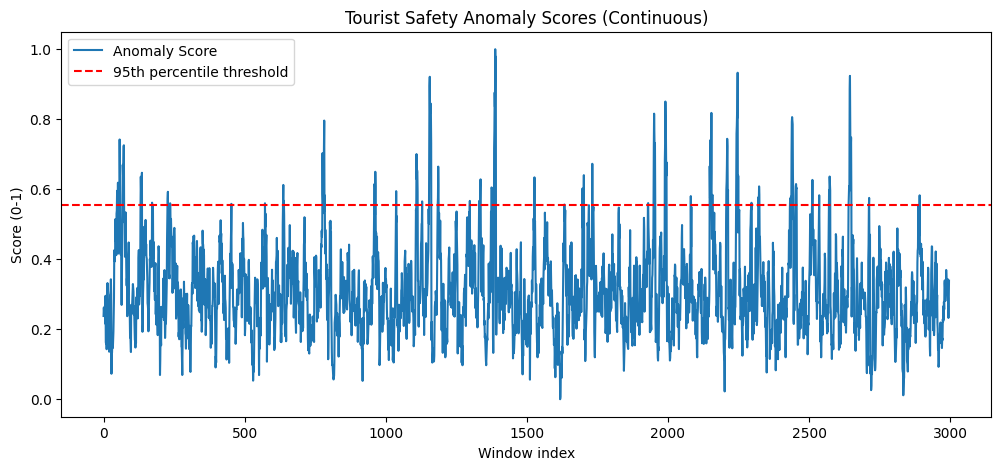

✅ Done. Scores saved as tourist_anomaly_scores_lstm.csv


NameError: name 'files' is not defined

In [ ]:
!pip install pandas numpy scikit-learn matplotlib tensorflow

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.losses import Huber

df = pd.read_csv("tourist_anomaly_dataset_10k.csv", parse_dates=["Timestamp"])
df.sort_values(["TouristID", "Timestamp"], inplace=True)

features = ["Speed", "DeviationFromRoute (m)", "StopDuration (min)", "SafetyScore", "AreaRiskIndex"]
X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

SEQ_LEN = 10
def create_sequences(data, seq_len=SEQ_LEN):
    sequences = []
    for i in range(len(data) - seq_len):
        seq = data[i:i+seq_len]
        sequences.append(seq)
    return np.array(sequences)

X_seq = create_sequences(X_scaled)

train_size = int(len(X_seq) * 0.7)
X_train, X_test = X_seq[:train_size], X_seq[train_size:]

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

model = Sequential([
    LSTM(64, activation='relu', input_shape=(SEQ_LEN, len(features)), return_sequences=False),
    RepeatVector(SEQ_LEN),
    LSTM(64, activation='relu', return_sequences=True),
    TimeDistributed(Dense(len(features)))
])
model.compile(optimizer='adam', loss=Huber())
model.summary()

history = model.fit(
    X_train, X_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    shuffle=True
)

X_test_pred = model.predict(X_test)
recon_errors = np.mean(np.square(X_test - X_test_pred), axis=(1,2))

anom_scores = (recon_errors - recon_errors.min()) / (recon_errors.max() - recon_errors.min() + 1e-9)

plt.figure(figsize=(12,5))
plt.plot(anom_scores, label="Anomaly Score")
plt.axhline(y=np.percentile(anom_scores, 95), color="r", linestyle="--", label="95th percentile threshold")
plt.legend()
plt.title("Tourist Safety Anomaly Scores (Continuous)")
plt.xlabel("Window index")
plt.ylabel("Score (0-1)")
plt.show()

print("✅ Done. Scores saved as tourist_anomaly_scores_lstm.csv")

DropOffFlag → Missing for long duration (>60 min gap).

JumpFlag → Impossible GPS jump (>5 km sudden shift).

InactivityFlag → Long stationary period (>20 min, speed <1).

DeviationFlag → Tourist is far from planned route (>100m).

FinalAlert → Combines all.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("tourist_anomaly_dataset_10k.csv")

df.columns = df.columns.str.replace(r"\s*\(.*?\)", "", regex=True)
df.columns = df.columns.str.replace(" ", "", regex=True)

df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df = df.sort_values(by=['TouristID','Timestamp']).reset_index(drop=True)


df['TimeDiff'] = df.groupby('TouristID')['Timestamp'].diff().dt.total_seconds().div(60)
df['DropOffFlag'] = (df['TimeDiff'] > 60).astype(int)

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2-lat1
    dlon = lon2-lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

df['PrevLat'] = df.groupby('TouristID')['Latitude'].shift()
df['PrevLon'] = df.groupby('TouristID')['Longitude'].shift()
df['DistJumpKm'] = haversine(df['PrevLat'], df['PrevLon'], df['Latitude'], df['Longitude'])
df['JumpFlag'] = ((df['DistJumpKm'] > 5) & (df['Speed'] < 5)).astype(int)

df['InactivityFlag'] = ((df['Speed'] < 1) & (df['StopDuration'] > 20)).astype(int)

df['DeviationFlag'] = (df['DeviationFromRoute'] > 100).astype(int)

df['FinalAlert'] = ((df['DropOffFlag']==1) |
                    (df['JumpFlag']==1) |
                    (df['InactivityFlag']==1) |
                    (df['DeviationFlag']==1)).astype(int)

print(df[['TouristID','Timestamp','Speed','StopDuration','DeviationFromRoute',
          'DropOffFlag','JumpFlag','InactivityFlag','DeviationFlag','FinalAlert']].head(20))

   TouristID           Timestamp      Speed  StopDuration  DeviationFromRoute  \
0       T001 2025-01-01 10:38:00  53.329843           148           52.748339   
1       T001 2025-01-01 20:53:00  50.301221            64           96.361719   
2       T001 2025-01-02 03:14:00  34.853440            27            1.015815   
3       T001 2025-01-02 12:21:00   0.459203            73           88.674292   
4       T001 2025-01-02 14:07:00  19.569729           147           35.947854   
5       T001 2025-01-02 17:41:00  51.846803            16           88.376643   
6       T001 2025-01-02 21:46:00  48.598063             4           87.874187   
7       T001 2025-01-02 22:22:00   5.063475            54          120.879210   
8       T001 2025-01-02 22:44:00  12.413977           158            6.132769   
9       T001 2025-01-03 00:42:00  34.696861            85            0.136153   
10      T001 2025-01-03 04:06:00  44.787755            37            2.228011   
11      T001 2025-01-03 04:1

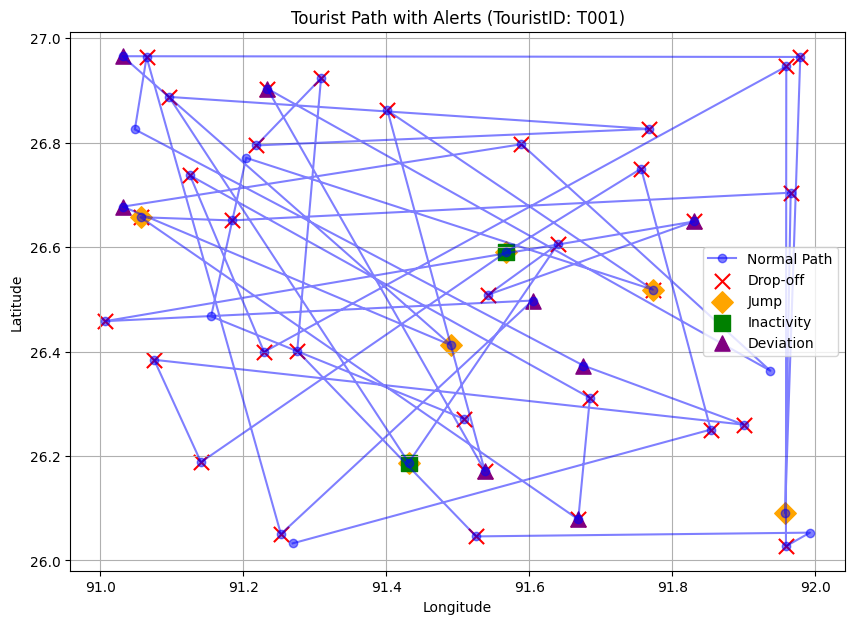

In [ ]:
import matplotlib.pyplot as plt

tourist_id = df['TouristID'].unique()[0]
tourist_data = df[df['TouristID'] == tourist_id]

plt.figure(figsize=(10,7))

plt.plot(tourist_data['Longitude'], tourist_data['Latitude'],
         marker='o', color='blue', alpha=0.5, label='Normal Path')

dropoff = tourist_data[tourist_data['DropOffFlag'] == 1]
jump = tourist_data[tourist_data['JumpFlag'] == 1]
inactivity = tourist_data[tourist_data['InactivityFlag'] == 1]
deviation = tourist_data[tourist_data['DeviationFlag'] == 1]

plt.scatter(dropoff['Longitude'], dropoff['Latitude'], color='red', s=120, label='Drop-off', marker='x')
plt.scatter(jump['Longitude'], jump['Latitude'], color='orange', s=120, label='Jump', marker='D')
plt.scatter(inactivity['Longitude'], inactivity['Latitude'], color='green', s=120, label='Inactivity', marker='s')
plt.scatter(deviation['Longitude'], deviation['Latitude'], color='purple', s=120, label='Deviation', marker='^')

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Tourist Path with Alerts (TouristID: {tourist_id})")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import folium

start_lat = tourist_data['Latitude'].iloc[0]
start_lon = tourist_data['Longitude'].iloc[0]

m = folium.Map(location=[start_lat, start_lon], zoom_start=13)

folium.PolyLine(
    list(zip(tourist_data['Latitude'], tourist_data['Longitude'])),
    color="blue", weight=2.5, opacity=0.8, tooltip="Path"
).add_to(m)

def add_markers(subset, label, color):
    for _, row in subset.iterrows():
        folium.Marker([row['Latitude'], row['Longitude']],
                      popup=f"{label} | Time: {row['Timestamp']}",
                      icon=folium.Icon(color=color, icon="exclamation-sign")).add_to(m)

add_markers(dropoff, "Drop-off", "red")
add_markers(jump, "Jump", "orange")
add_markers(inactivity, "Inactivity", "green")
add_markers(deviation, "Deviation", "purple")

m

In [ ]:
import folium

start_lat = tourist_data['Latitude'].iloc[0]
start_lon = tourist_data['Longitude'].iloc[0]

m = folium.Map(location=[start_lat, start_lon], zoom_start=13)

folium.PolyLine(
    list(zip(tourist_data['Latitude'], tourist_data['Longitude'])),
    color="blue", weight=2.5, opacity=0.8, tooltip="Path"
).add_to(m)

def add_markers(subset, label, color):
    for _, row in subset.iterrows():
        lat, lon = row['Latitude'], row['Longitude']
        folium.Marker(
            [lat, lon],
            popup=f"{label} | Time: {row['Timestamp']} | ({lat:.5f}, {lon:.5f})",
            tooltip=f"{label}: ({lat:.5f}, {lon:.5f})",
            icon=folium.Icon(color=color, icon="info-sign")
        ).add_to(m)
        print(f"{label} → Time: {row['Timestamp']} | Lat: {lat:.5f}, Lon: {lon:.5f}")

add_markers(dropoff, "Drop-off", "red")
add_markers(jump, "Jump", "orange")
add_markers(inactivity, "Inactivity", "green")
add_markers(deviation, "Deviation", "purple")

print("\n📍 Full Tourist Path Coordinates:")
for _, row in tourist_data.iterrows():
    print(f"Time: {row['Timestamp']} | Lat: {row['Latitude']:.5f}, Lon: {row['Longitude']:.5f}")

m

Drop-off → Time: 2025-01-01 20:53:00 | Lat: 26.25052, Lon: 91.85360
Drop-off → Time: 2025-01-02 03:14:00 | Lat: 26.75013, Lon: 91.75637
Drop-off → Time: 2025-01-02 12:21:00 | Lat: 26.59046, Lon: 91.56770
Drop-off → Time: 2025-01-02 14:07:00 | Lat: 26.18819, Lon: 91.14099
Drop-off → Time: 2025-01-02 17:41:00 | Lat: 26.38415, Lon: 91.07551
Drop-off → Time: 2025-01-02 21:46:00 | Lat: 26.25998, Lon: 91.89969
Drop-off → Time: 2025-01-03 00:42:00 | Lat: 26.96350, Lon: 91.06496
Drop-off → Time: 2025-01-03 04:06:00 | Lat: 26.05056, Lon: 91.25275
Drop-off → Time: 2025-01-03 08:02:00 | Lat: 26.45813, Lon: 91.00737
Drop-off → Time: 2025-01-03 10:44:00 | Lat: 26.64897, Lon: 91.83051
Drop-off → Time: 2025-01-03 15:07:00 | Lat: 26.50873, Lon: 91.54242
Drop-off → Time: 2025-01-03 20:36:00 | Lat: 26.60564, Lon: 91.64011
Drop-off → Time: 2025-01-04 03:01:00 | Lat: 26.18717, Lon: 91.43130
Drop-off → Time: 2025-01-04 06:44:00 | Lat: 26.88743, Lon: 91.09638
Drop-off → Time: 2025-01-04 11:14:00 | Lat: 26.8

What this does
MissingFlag → Detects missing behaviour (e.g., prolonged no-data / >30 min stop).

SilentFlag → Detects silent behaviour (not moving, no speed, long stop).

DistressFlag → Detects distress (stuck in high-risk area).
FinalAlert → Unified flag (from anomaly + rules).

In [ ]:
import pandas as pd

df = pd.read_csv("tourist_anomaly_dataset_10k.csv")

df.columns = df.columns.str.replace(r"\s*\(.*?\)", "", regex=True)
df.columns = df.columns.str.replace(" ", "", regex=True)

print("✅ Cleaned Columns:", df.columns.tolist())

df['MissingFlag'] = (df['StopDuration'] > 30).astype(int)

df['SilentFlag'] = ((df['Speed'] < 1) & (df['StopDuration'] > 10)).astype(int)

df['DistressFlag'] = ((df['StopDuration'] > 5) & (df['GeoFenceZone'] == 'HighRisk')).astype(int)

df['AnomalyScore'] = (100 - df['SafetyScore']) / 100

df['FinalAlert'] = ((df['AnomalyScore'] > 0.6) |
                    (df['MissingFlag'] == 1) |
                    (df['SilentFlag'] == 1) |
                    (df['DistressFlag'] == 1)).astype(int)

print(df[['TouristID','Timestamp','Speed','StopDuration','GeoFenceZone',
          'AnomalyScore','MissingFlag','SilentFlag','DistressFlag','FinalAlert']].head(20))

✅ Cleaned Columns: ['TouristID', 'Timestamp', 'Latitude', 'Longitude', 'Speed', 'Altitude', 'PlannedRouteID', 'DeviationFromRoute', 'StopDuration', 'GeoFenceZone', 'SafetyScore', 'WeatherCondition', 'AreaRiskIndex', 'AnomalyFlag', 'AlertGenerated']
   TouristID            Timestamp      Speed  StopDuration GeoFenceZone  \
0       T181  2025-01-01 08:00:00  24.811649            46         Safe   
1       T044  2025-01-01 08:01:00  28.756569            45         Safe   
2       T116  2025-01-01 08:02:00  17.807724           100         Safe   
3       T015  2025-01-01 08:03:00  26.098732           135      Unknown   
4       T051  2025-01-01 08:04:00  13.518423            31         Safe   
5       T021  2025-01-01 08:05:00  23.656175            68     HighRisk   
6       T116  2025-01-01 08:06:00   1.608080           166         Safe   
7       T038  2025-01-01 08:07:00   2.244290            52     HighRisk   
8       T066  2025-01-01 08:08:00   6.297093            98         Safe   
9

In [ ]:
model.save('lstm_anomaly_model.h5')

✅ LSTM model saved as lstm_anomaly_model.h5


In [ ]:
import pickle

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Scaler saved as scaler.pkl")

✅ Scaler saved as scaler.pkl


In [ ]:
print(model.input_shape)

(None, 10, 5)


In [ ]:
import numpy as np
from datetime import datetime
import random

def predict_tourist_safety(tourist_id: str, speed: float, deviation: float, stop_duration: float, safety_score: float, area_risk: float):
    """
    Predicts tourist safety anomalies using your trained LSTM model

    Args:
        tourist_id: Tourist identifier (e.g., "T001")
        speed: Current speed in km/h
        deviation: Route deviation in meters
        stop_duration: Stop duration in minutes
        safety_score: Safety score 0-100
        area_risk: Area risk index 0-1

    Returns:
        dict: Complete safety analysis with predictions
    """

    features = np.array([speed, deviation, stop_duration, safety_score, area_risk]).reshape(1, -1)

    features_scaled = scaler.transform(features)

    sequence = np.tile(features_scaled, (1, SEQ_LEN, 1))

    try:
        reconstruction = model.predict(sequence, verbose=0)
        reconstruction_error = np.mean(np.square(sequence - reconstruction))

        ml_anomaly_score = min(reconstruction_error * 3, 1.0)

    except:
        ml_anomaly_score = 0.5

    rule_flags = {
        'inactivity_alert': speed < 1 and stop_duration > 20,
        'deviation_alert': deviation > 100,
        'high_risk_area': area_risk > 0.7,
        'low_safety_score': safety_score < 40,
        'prolonged_stop': stop_duration > 60
    }

    rule_score = sum(rule_flags.values()) / len(rule_flags)

    combined_score = (ml_anomaly_score * 0.7) + (rule_score * 0.3)

    if combined_score > 0.8:
        risk_level = "CRITICAL"
        alert_msg = f"🚨 EMERGENCY: Tourist {tourist_id} needs immediate help!"
    elif combined_score > 0.6:
        risk_level = "HIGH"
        alert_msg = f"⚠️ HIGH RISK: Monitor tourist {tourist_id} closely"
    elif combined_score > 0.4:
        risk_level = "MEDIUM"
        alert_msg = f"🟡 MEDIUM RISK: Keep watching tourist {tourist_id}"
    else:
        risk_level = "LOW"
        alert_msg = f"✅ LOW RISK: Tourist {tourist_id} appears safe"

    active_alerts = []
    if rule_flags['inactivity_alert']:
        active_alerts.append(f"Inactive for {stop_duration} minutes")
    if rule_flags['deviation_alert']:
        active_alerts.append(f"Route deviation: {deviation}m")
    if rule_flags['high_risk_area']:
        active_alerts.append("Currently in high-risk area")
    if rule_flags['prolonged_stop']:
        active_alerts.append("Stopped for extended period")

    return {
        "tourist_id": tourist_id,
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "ml_anomaly_score": round(ml_anomaly_score, 3),
        "rule_score": round(rule_score, 3),
        "combined_score": round(combined_score, 3),
        "risk_level": risk_level,
        "alert_required": combined_score > 0.6,
        "message": alert_msg,
        "active_alerts": active_alerts,
        "input_data": {
            "speed_kmh": speed,
            "deviation_m": deviation,
            "stop_duration_min": stop_duration,
            "safety_score": safety_score,
            "area_risk": area_risk
        },
        "recommendations": get_recommendations(risk_level, active_alerts)
    }

def get_recommendations(risk_level, alerts):
    """Generate recommendations based on risk level"""
    if risk_level == "CRITICAL":
        return ["🚨 Call emergency services", "📞 Contact tourist immediately", "🚓 Send police to location"]
    elif risk_level == "HIGH":
        return ["📱 Try contacting tourist", "👮 Notify local authorities", "📍 Track location closely"]
    elif risk_level == "MEDIUM":
        return ["📲 Send safety check message", "⏰ Monitor for next 30 minutes"]
    else:
        return ["✅ Continue normal monitoring"]

def test_prediction():
    """Test the prediction function with sample data"""

    test_cases = [
        {"tourist_id": "T001", "speed": 5.0, "deviation": 20, "stop_duration": 5, "safety_score": 85, "area_risk": 0.2},

        {"tourist_id": "T002", "speed": 0.0, "deviation": 10, "stop_duration": 45, "safety_score": 70, "area_risk": 0.3},

        {"tourist_id": "T003", "speed": 2.0, "deviation": 150, "stop_duration": 15, "safety_score": 40, "area_risk": 0.9},

        {"tourist_id": "T004", "speed": 0.0, "deviation": 300, "stop_duration": 120, "safety_score": 20, "area_risk": 0.8}
    ]

    print("🤖 Testing Tourist Safety Predictions:\n")
    for i, test in enumerate(test_cases, 1):
        result = predict_tourist_safety(**test)
        print(f"Test {i}: {result['message']}")
        print(f"   Risk Level: {result['risk_level']}")
        print(f"   Combined Score: {result['combined_score']}")
        if result['active_alerts']:
            print(f"   Alerts: {', '.join(result['active_alerts'])}")
        print("-" * 50)

if __name__ == "__main__":
    tourist_id_input = input("Enter Tourist ID (e.g., T001): ")
    speed_input = float(input("Enter current speed (km/h): "))
    deviation_input = float(input("Enter route deviation (m): "))
    stop_duration_input = float(input("Enter stop duration (minutes): "))
    safety_score_input = float(input("Enter safety score (0-100): "))
    area_risk_input = float(input("Enter area risk index (0-1): "))


    result = predict_tourist_safety(
        tourist_id=tourist_id_input,
        speed=speed_input,
        deviation=deviation_input,
        stop_duration=stop_duration_input,
        safety_score=safety_score_input,
        area_risk=area_risk_input
    )

    print("\n🎯 Prediction Result:")
    print(f"Tourist: {result['tourist_id']}")
    print(f"Risk Level: {result['risk_level']}")
    print(f"Message: {result['message']}")
    print(f"ML Score: {result['ml_anomaly_score']}")
    print(f"Rule Score: {result['rule_score']}")
    print(f"Combined Score: {result['combined_score']}")

    if result['active_alerts']:
        print(f"Active Alerts: {result['active_alerts']}")

Enter Tourist ID (e.g., T001): 004
Enter current speed (km/h): 12
Enter route deviation (m): 22
Enter stop duration (minutes): 12
Enter safety score (0-100): 12
Enter area risk index (0-1): 1

🎯 Prediction Result:
Tourist: 004
Risk Level: MEDIUM
Message: 🟡 MEDIUM RISK: Keep watching tourist 004
ML Score: 0.609
Rule Score: 0.4
Combined Score: 0.546
Active Alerts: ['Currently in high-risk area']


In [ ]:
import requests
import json

data = {
    "data": [2, 50, 0, 0, 50, 0]  # [tourist_id, speed, deviation, stop_duration, safety_score, area_risk]
}

url = "https://nsut-ac.us-east-2.aws.modelbit.com/v1/predict_tourist_safety/latest"

response = requests.post(url, json=data)
print(response.json())


{'data': {'tourist_id': 2, 'timestamp': '2025-09-20 17:19:40', 'ml_anomaly_score': 0.363, 'rule_score': 0, 'combined_score': 0.254, 'risk_level': 'LOW', 'alert_required': False, 'message': '✅ LOW RISK: Tourist 2 appears safe', 'active_alerts': [], 'input_data': {'speed_kmh': 50, 'deviation_m': 0, 'stop_duration_min': 0, 'safety_score': 50, 'area_risk': 0}, 'recommendations': ['✅ Continue normal monitoring']}}


In [ ]:
!curl -s -XPOST "https://nsut-ac.us-east-2.aws.modelbit.com/v1/predict_tourist_safety/latest" \
-d '{"data": [2, 50, 0, 0, 50, 0]}' | json_pp


{
   "data" : {
      "active_alerts" : [],
      "alert_required" : false,
      "combined_score" : 0.254,
      "input_data" : {
         "area_risk" : 0,
         "deviation_m" : 0,
         "safety_score" : 50,
         "speed_kmh" : 50,
         "stop_duration_min" : 0
      },
      "message" : "✅ LOW RISK: Tourist 2 appears safe",
      "ml_anomaly_score" : 0.363,
      "recommendations" : [
         "✅ Continue normal monitoring"
      ],
      "risk_level" : "LOW",
      "rule_score" : 0,
      "timestamp" : "2025-09-20 17:19:42",
      "tourist_id" : 2
   }
}


In [ ]:
import folium

tourist_path = [
    {"time": "2025-01-01 10:38:00", "lat": 26.03271, "lon": 91.26916},
    {"time": "2025-01-01 20:53:00", "lat": 26.25052, "lon": 91.85360},
    {"time": "2025-01-02 03:14:00", "lat": 26.75013, "lon": 91.75637},
    {"time": "2025-01-02 12:21:00", "lat": 26.59046, "lon": 91.56770},
    {"time": "2025-01-02 14:07:00", "lat": 26.18819, "lon": 91.14099},
    {"time": "2025-01-02 17:41:00", "lat": 26.38415, "lon": 91.07551},
    {"time": "2025-01-02 21:46:00", "lat": 26.25998, "lon": 91.89969},
    {"time": "2025-01-02 22:22:00", "lat": 26.37311, "lon": 91.67559},
    {"time": "2025-01-02 22:44:00", "lat": 26.82521, "lon": 91.04859},
    {"time": "2025-01-03 00:42:00", "lat": 26.96350, "lon": 91.06496},
    {"time": "2025-01-03 04:06:00", "lat": 26.05056, "lon": 91.25275},
    {"time": "2025-01-03 04:17:00", "lat": 26.49756, "lon": 91.60452},
    {"time": "2025-01-03 08:02:00", "lat": 26.45813, "lon": 91.00737},
    {"time": "2025-01-03 10:44:00", "lat": 26.64897, "lon": 91.83051},
    {"time": "2025-01-03 15:07:00", "lat": 26.50873, "lon": 91.54242},
    {"time": "2025-01-03 20:36:00", "lat": 26.60564, "lon": 91.64011},
    {"time": "2025-01-04 03:01:00", "lat": 26.18717, "lon": 91.43130},
    {"time": "2025-01-04 06:44:00", "lat": 26.88743, "lon": 91.09638},
    {"time": "2025-01-04 11:14:00", "lat": 26.82609, "lon": 91.76700},
    {"time": "2025-01-04 18:30:00", "lat": 26.79456, "lon": 91.21846},
    {"time": "2025-01-04 23:05:00", "lat": 26.92300, "lon": 91.30884},
    {"time": "2025-01-05 00:39:00", "lat": 26.40118, "lon": 91.27556},
    {"time": "2025-01-05 02:58:00", "lat": 26.04604, "lon": 91.52564},
    {"time": "2025-01-05 03:26:00", "lat": 26.05324, "lon": 91.99229},
    {"time": "2025-01-05 05:31:00", "lat": 26.02724, "lon": 91.95877},
    {"time": "2025-01-05 06:46:00", "lat": 26.94572, "lon": 91.95925},
    {"time": "2025-01-05 07:59:00", "lat": 26.39922, "lon": 91.22922},
    {"time": "2025-01-05 14:02:00", "lat": 26.73715, "lon": 91.12565},
    {"time": "2025-01-05 17:17:00", "lat": 26.31125, "lon": 91.68474},
    {"time": "2025-01-05 18:27:00", "lat": 26.07865, "lon": 91.66841},
    {"time": "2025-01-06 08:39:00", "lat": 26.65713, "lon": 91.05647},
    {"time": "2025-01-06 16:13:00", "lat": 26.65093, "lon": 91.18386},
    {"time": "2025-01-06 17:43:00", "lat": 26.70398, "lon": 91.96540},
    {"time": "2025-01-06 18:16:00", "lat": 26.09033, "lon": 91.95754},
    {"time": "2025-01-07 04:39:00", "lat": 26.96391, "lon": 91.97879},
    {"time": "2025-01-07 05:12:00", "lat": 26.96529, "lon": 91.03132},
    {"time": "2025-01-07 05:31:00", "lat": 26.41218, "lon": 91.49058},
    {"time": "2025-01-07 06:29:00", "lat": 26.67732, "lon": 91.03192},
    {"time": "2025-01-07 08:08:00", "lat": 26.79680, "lon": 91.58906},
    {"time": "2025-01-07 08:40:00", "lat": 26.36312, "lon": 91.93699},
    {"time": "2025-01-07 10:40:00", "lat": 26.90335, "lon": 91.23365},
    {"time": "2025-01-07 13:53:00", "lat": 26.17136, "lon": 91.53780},
    {"time": "2025-01-07 17:11:00", "lat": 26.86139, "lon": 91.40173},
    {"time": "2025-01-08 04:15:00", "lat": 26.51842, "lon": 91.77268},
    {"time": "2025-01-08 05:07:00", "lat": 26.77073, "lon": 91.20422},
    {"time": "2025-01-08 05:15:00", "lat": 26.46734, "lon": 91.15514},
    {"time": "2025-01-08 06:33:00", "lat": 26.27114, "lon": 91.50863},
]

anomalies = {
    "Drop-off": [
        {"time": "2025-01-02 22:22:00", "lat": 26.37311, "lon": 91.67559},
        {"time": "2025-01-03 10:44:00", "lat": 26.64897, "lon": 91.83051},
        {"time": "2025-01-04 03:01:00", "lat": 26.18717, "lon": 91.43130}
    ],
    "Jump": [
        {"time": "2025-01-02 21:46:00", "lat": 26.25998, "lon": 91.89969},
        {"time": "2025-01-05 03:26:00", "lat": 26.05324, "lon": 91.99229},
        {"time": "2025-01-06 18:16:00", "lat": 26.09033, "lon": 91.95754}
    ],
    "Inactivity": [
        {"time": "2025-01-03 00:42:00", "lat": 26.96350, "lon": 91.06496},
        {"time": "2025-01-05 06:46:00", "lat": 26.94572, "lon": 91.95925},
        {"time": "2025-01-07 04:39:00", "lat": 26.96391, "lon": 91.97879}
    ],
    "Deviation": [
        {"time": "2025-01-02 22:44:00", "lat": 26.82521, "lon": 91.04859},
        {"time": "2025-01-05 14:02:00", "lat": 26.73715, "lon": 91.12565},
        {"time": "2025-01-07 08:08:00", "lat": 26.79680, "lon": 91.58906}
    ]
}


def create_tourist_map(tourist_path, anomalies):
    start_lat, start_lon = tourist_path[0]["lat"], tourist_path[0]["lon"]
    m = folium.Map(location=[start_lat, start_lon], zoom_start=10)

    folium.PolyLine(
        [(p["lat"], p["lon"]) for p in tourist_path],
        color="blue", weight=2.5, opacity=0.8, tooltip="Tourist Path"
    ).add_to(m)

    colors = {"Drop-off": "red", "Jump": "orange", "Inactivity": "green", "Deviation": "purple"}
    for label, points in anomalies.items():
        for p in points:
            folium.Marker(
                [p["lat"], p["lon"]],
                popup=f"{label} | Time: {p['time']}",
                icon=folium.Icon(color=colors[label], icon="exclamation-sign")
            ).add_to(m)

    return m

m = create_tourist_map(tourist_path, anomalies)
m.save("tourist_map.html")
m = create_tourist_map(tourist_path, anomalies)
m



In [ ]:
import folium
from typing import List, Dict, Optional
from selenium import webdriver
from selenium.webdriver.chrome.options import Options

def create_tourist_map_png(
    tourist_path: Optional[List[Dict]] = None,
    anomalies: Optional[Dict[str, List[Dict]]] = None
) -> Dict[str, str]:
    """
    Returns a Base64 PNG image of the Folium map for API usage.

    Output:
        {"map_base64": "<base64 string>"}
    """

    if tourist_path is None:
        tourist_path = [
           {"time": "2025-01-01 10:38:00", "lat": 26.03271, "lon": 91.26916},
                {"time": "2025-01-01 20:53:00", "lat": 26.25052, "lon": 91.85360},
                {"time": "2025-01-02 03:14:00", "lat": 26.75013, "lon": 91.75637},
                {"time": "2025-01-02 12:21:00", "lat": 26.59046, "lon": 91.56770},
                {"time": "2025-01-02 14:07:00", "lat": 26.18819, "lon": 91.14099},
                {"time": "2025-01-02 17:41:00", "lat": 26.38415, "lon": 91.07551},
                {"time": "2025-01-02 21:46:00", "lat": 26.25998, "lon": 91.89969},
                {"time": "2025-01-02 22:22:00", "lat": 26.37311, "lon": 91.67559},
                {"time": "2025-01-02 22:44:00", "lat": 26.82521, "lon": 91.04859},
                {"time": "2025-01-03 00:42:00", "lat": 26.96350, "lon": 91.06496},
                {"time": "2025-01-03 04:06:00", "lat": 26.05056, "lon": 91.25275},
                {"time": "2025-01-03 04:17:00", "lat": 26.49756, "lon": 91.60452},
                {"time": "2025-01-03 08:02:00", "lat": 26.45813, "lon": 91.00737},
                {"time": "2025-01-03 10:44:00", "lat": 26.64897, "lon": 91.83051},
                {"time": "2025-01-03 15:07:00", "lat": 26.50873, "lon": 91.54242},
                {"time": "2025-01-03 20:36:00", "lat": 26.60564, "lon": 91.64011},
                {"time": "2025-01-04 03:01:00", "lat": 26.18717, "lon": 91.43130},
                {"time": "2025-01-04 06:44:00", "lat": 26.88743, "lon": 91.09638},
                {"time": "2025-01-04 11:14:00", "lat": 26.82609, "lon": 91.76700},
                {"time": "2025-01-04 18:30:00", "lat": 26.79456, "lon": 91.21846},
                {"time": "2025-01-04 23:05:00", "lat": 26.92300, "lon": 91.30884},
                {"time": "2025-01-05 00:39:00", "lat": 26.40118, "lon": 91.27556},
                {"time": "2025-01-05 02:58:00", "lat": 26.04604, "lon": 91.52564},
                {"time": "2025-01-05 03:26:00", "lat": 26.05324, "lon": 91.99229},
                {"time": "2025-01-05 05:31:00", "lat": 26.02724, "lon": 91.95877},
                {"time": "2025-01-05 06:46:00", "lat": 26.94572, "lon": 91.95925},
                {"time": "2025-01-05 07:59:00", "lat": 26.39922, "lon": 91.22922},
                {"time": "2025-01-05 14:02:00", "lat": 26.73715, "lon": 91.12565},
                {"time": "2025-01-05 17:17:00", "lat": 26.31125, "lon": 91.68474},
                {"time": "2025-01-05 18:27:00", "lat": 26.07865, "lon": 91.66841},
                {"time": "2025-01-06 08:39:00", "lat": 26.65713, "lon": 91.05647},
                {"time": "2025-01-06 16:13:00", "lat": 26.65093, "lon": 91.18386},
                {"time": "2025-01-06 17:43:00", "lat": 26.70398, "lon": 91.96540},
                {"time": "2025-01-06 18:16:00", "lat": 26.09033, "lon": 91.95754},
                {"time": "2025-01-07 04:39:00", "lat": 26.96391, "lon": 91.97879},
                {"time": "2025-01-07 05:12:00", "lat": 26.96529, "lon": 91.03132},
                {"time": "2025-01-07 05:31:00", "lat": 26.41218, "lon": 91.49058},
                {"time": "2025-01-07 06:29:00", "lat": 26.67732, "lon": 91.03192},
                {"time": "2025-01-07 08:08:00", "lat": 26.79680, "lon": 91.58906},
                {"time": "2025-01-07 08:40:00", "lat": 26.36312, "lon": 91.93699},
                {"time": "2025-01-07 10:40:00", "lat": 26.90335, "lon": 91.23365},
                {"time": "2025-01-07 13:53:00", "lat": 26.17136, "lon": 91.53780},
                {"time": "2025-01-07 17:11:00", "lat": 26.86139, "lon": 91.40173},
                {"time": "2025-01-08 04:15:00", "lat": 26.51842, "lon": 91.77268},
                {"time": "2025-01-08 05:07:00", "lat": 26.77073, "lon": 91.20422},
                {"time": "2025-01-08 05:15:00", "lat": 26.46734, "lon": 91.15514},
                {"time": "2025-01-08 06:33:00", "lat": 26.27114, "lon": 91.50863}
        ]

    if anomalies is None:
        anomalies = {

            "Drop-off": [
        {"time": "2025-01-02 22:22:00", "lat": 26.37311, "lon": 91.67559},
        {"time": "2025-01-03 10:44:00", "lat": 26.64897, "lon": 91.83051},
        {"time": "2025-01-04 03:01:00", "lat": 26.18717, "lon": 91.43130}
    ],
    "Jump": [
        {"time": "2025-01-02 21:46:00", "lat": 26.25998, "lon": 91.89969},
        {"time": "2025-01-05 03:26:00", "lat": 26.05324, "lon": 91.99229},
        {"time": "2025-01-06 18:16:00", "lat": 26.09033, "lon": 91.95754}
    ],
    "Inactivity": [
        {"time": "2025-01-03 00:42:00", "lat": 26.96350, "lon": 91.06496},
        {"time": "2025-01-05 06:46:00", "lat": 26.94572, "lon": 91.95925},
        {"time": "2025-01-07 04:39:00", "lat": 26.96391, "lon": 91.97879}
    ],
    "Deviation": [
        {"time": "2025-01-02 22:44:00", "lat": 26.82521, "lon": 91.04859},
        {"time": "2025-01-05 14:02:00", "lat": 26.73715, "lon": 91.12565},
        {"time": "2025-01-07 08:08:00", "lat": 26.79680, "lon": 91.58906}
    ]
        }

    start_lat, start_lon = tourist_path[0]["lat"], tourist_path[0]["lon"]
    m = folium.Map(location=[start_lat, start_lon], zoom_start=10)
    folium.PolyLine([(p["lat"], p["lon"]) for p in tourist_path], color="blue").add_to(m)

    colors = {"Drop-off": "red", "Jump": "orange", "Inactivity": "green", "Deviation": "purple"}
    for label, points in anomalies.items():
        for p in points:
            folium.Marker([p["lat"], p["lon"]],
                          popup=f"{label} | Time: {p['time']}",
                          icon=folium.Icon(color=colors.get(label, "blue"))).add_to(m)

    html_file = "temp_map.html"
    m.save(html_file)

    chrome_options = Options()
    chrome_options.add_argument("--headless")
    chrome_options.add_argument("--window-size=1200,800")
    driver = webdriver.Chrome(options=chrome_options)
    driver.get(f"file://{os.path.abspath(html_file)}")
    png = driver.get_screenshot_as_png()
    driver.quit()

    map_base64 = base64.b64encode(png).decode("utf-8")

    os.remove(html_file)

    return {"map_base64": map_base64}

In [ ]:
!pip install selenium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 499.2/499.2 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 2.8 MB/s eta 0:00:00
  Attempting uninstall: typing_extensions
    Found existing installation: typing_extensions 4.15.0
    Uninstalling typing_extensions-4.15.0:
      Successfully uninstalled typing_extensions-4.15.0


In [ ]:
import folium
import os
import base64
from typing import List, Dict, Optional
from selenium import webdriver
from selenium.webdriver.chrome.options import Options

def create_tourist_map_png(
    tourist_path: Optional[List[Dict]] = None,
    anomalies: Optional[Dict[str, List[Dict]]] = None
) -> Dict[str, str]:
    """
    Returns a Base64 PNG image of the Folium map for API usage.

    Output:
        {"map_base64": "<base64 string>"}
    """

    if tourist_path is None:
        tourist_path = [
            {"time": "2025-01-01 10:38:00", "lat": 26.03271, "lon": 91.26916},
                {"time": "2025-01-01 20:53:00", "lat": 26.25052, "lon": 91.85360},
                {"time": "2025-01-02 03:14:00", "lat": 26.75013, "lon": 91.75637},
                {"time": "2025-01-02 12:21:00", "lat": 26.59046, "lon": 91.56770},
                {"time": "2025-01-02 14:07:00", "lat": 26.18819, "lon": 91.14099},
                {"time": "2025-01-02 17:41:00", "lat": 26.38415, "lon": 91.07551},
                {"time": "2025-01-02 21:46:00", "lat": 26.25998, "lon": 91.89969},
                {"time": "2025-01-02 22:22:00", "lat": 26.37311, "lon": 91.67559},
                {"time": "2025-01-02 22:44:00", "lat": 26.82521, "lon": 91.04859},
                {"time": "2025-01-03 00:42:00", "lat": 26.96350, "lon": 91.06496},
                {"time": "2025-01-03 04:06:00", "lat": 26.05056, "lon": 91.25275},
                {"time": "2025-01-03 04:17:00", "lat": 26.49756, "lon": 91.60452},
                {"time": "2025-01-03 08:02:00", "lat": 26.45813, "lon": 91.00737},
                {"time": "2025-01-03 10:44:00", "lat": 26.64897, "lon": 91.83051},
                {"time": "2025-01-03 15:07:00", "lat": 26.50873, "lon": 91.54242},
                {"time": "2025-01-03 20:36:00", "lat": 26.60564, "lon": 91.64011},
                {"time": "2025-01-04 03:01:00", "lat": 26.18717, "lon": 91.43130},
                {"time": "2025-01-04 06:44:00", "lat": 26.88743, "lon": 91.09638},
                {"time": "2025-01-04 11:14:00", "lat": 26.82609, "lon": 91.76700},
                {"time": "2025-01-04 18:30:00", "lat": 26.79456, "lon": 91.21846},
                {"time": "2025-01-04 23:05:00", "lat": 26.92300, "lon": 91.30884},
                {"time": "2025-01-05 00:39:00", "lat": 26.40118, "lon": 91.27556},
                {"time": "2025-01-05 02:58:00", "lat": 26.04604, "lon": 91.52564},
                {"time": "2025-01-05 03:26:00", "lat": 26.05324, "lon": 91.99229},
                {"time": "2025-01-05 05:31:00", "lat": 26.02724, "lon": 91.95877},
                {"time": "2025-01-05 06:46:00", "lat": 26.94572, "lon": 91.95925},
                {"time": "2025-01-05 07:59:00", "lat": 26.39922, "lon": 91.22922},
                {"time": "2025-01-05 14:02:00", "lat": 26.73715, "lon": 91.12565},
                {"time": "2025-01-05 17:17:00", "lat": 26.31125, "lon": 91.68474},
                {"time": "2025-01-05 18:27:00", "lat": 26.07865, "lon": 91.66841},
                {"time": "2025-01-06 08:39:00", "lat": 26.65713, "lon": 91.05647},
                {"time": "2025-01-06 16:13:00", "lat": 26.65093, "lon": 91.18386},
                {"time": "2025-01-06 17:43:00", "lat": 26.70398, "lon": 91.96540},
                {"time": "2025-01-06 18:16:00", "lat": 26.09033, "lon": 91.95754},
                {"time": "2025-01-07 04:39:00", "lat": 26.96391, "lon": 91.97879},
                {"time": "2025-01-07 05:12:00", "lat": 26.96529, "lon": 91.03132},
                {"time": "2025-01-07 05:31:00", "lat": 26.41218, "lon": 91.49058},
                {"time": "2025-01-07 06:29:00", "lat": 26.67732, "lon": 91.03192},
                {"time": "2025-01-07 08:08:00", "lat": 26.79680, "lon": 91.58906},
                {"time": "2025-01-07 08:40:00", "lat": 26.36312, "lon": 91.93699},
                {"time": "2025-01-07 10:40:00", "lat": 26.90335, "lon": 91.23365},
                {"time": "2025-01-07 13:53:00", "lat": 26.17136, "lon": 91.53780},
                {"time": "2025-01-07 17:11:00", "lat": 26.86139, "lon": 91.40173},
                {"time": "2025-01-08 04:15:00", "lat": 26.51842, "lon": 91.77268},
                {"time": "2025-01-08 05:07:00", "lat": 26.77073, "lon": 91.20422},
                {"time": "2025-01-08 05:15:00", "lat": 26.46734, "lon": 91.15514},
                {"time": "2025-01-08 06:33:00", "lat": 26.27114, "lon": 91.50863}
        ]

    if anomalies is None:
        anomalies = {

            "Drop-off": [
        {"time": "2025-01-02 22:22:00", "lat": 26.37311, "lon": 91.67559},
        {"time": "2025-01-03 10:44:00", "lat": 26.64897, "lon": 91.83051},
        {"time": "2025-01-04 03:01:00", "lat": 26.18717, "lon": 91.43130}
    ],
    "Jump": [
        {"time": "2025-01-02 21:46:00", "lat": 26.25998, "lon": 91.89969},
        {"time": "2025-01-05 03:26:00", "lat": 26.05324, "lon": 91.99229},
        {"time": "2025-01-06 18:16:00", "lat": 26.09033, "lon": 91.95754}
    ],
    "Inactivity": [
        {"time": "2025-01-03 00:42:00", "lat": 26.96350, "lon": 91.06496},
        {"time": "2025-01-05 06:46:00", "lat": 26.94572, "lon": 91.95925},
        {"time": "2025-01-07 04:39:00", "lat": 26.96391, "lon": 91.97879}
    ],
    "Deviation": [
        {"time": "2025-01-02 22:44:00", "lat": 26.82521, "lon": 91.04859},
        {"time": "2025-01-05 14:02:00", "lat": 26.73715, "lon": 91.12565},
        {"time": "2025-01-07 08:08:00", "lat": 26.79680, "lon": 91.58906}
    ]
        }

    start_lat, start_lon = tourist_path[0]["lat"], tourist_path[0]["lon"]
    m = folium.Map(location=[start_lat, start_lon], zoom_start=10)
    folium.PolyLine([(p["lat"], p["lon"]) for p in tourist_path], color="blue").add_to(m)

    colors = {"Drop-off": "red", "Jump": "orange", "Inactivity": "green", "Deviation": "purple"}
    for label, points in anomalies.items():
        for p in points:
            folium.Marker([p["lat"], p["lon"]],
                          popup=f"{label} | Time: {p['time']}",
                          icon=folium.Icon(color=colors.get(label, "blue"))).add_to(m)

    html_file = "temp_map.html"
    m.save(html_file)


    chrome_options = Options()
    chrome_options.add_argument("--headless")
    chrome_options.add_argument("--window-size=1200,800")
    driver = webdriver.Chrome(options=chrome_options)
    driver.get(f"file://{os.path.abspath(html_file)}")
    png = driver.get_screenshot_as_png()
    driver.quit()


    map_base64 = base64.b64encode(png).decode("utf-8")

    os.remove(html_file)

    return {"map_base64": map_base64}



In [ ]:
!pip install modelbit
import modelbit
mb = modelbit.login()

In [ ]:
mb.deploy(create_tourist_map)

In [ ]:
import json
import subprocess

payload = json.dumps([tourist_path, anomalies])

subprocess.run([
    "curl", "-s", "-XPOST",
    "https://nsut-ac.us-east-2.aws.modelbit.com/v1/create_tourist_map/latest",
    "-H", "Content-Type: application/json",
    "-d", payload
])


CompletedProcess(args=['curl', '-s', '-XPOST', 'https://nsut-ac.us-east-2.aws.modelbit.com/v1/create_tourist_map/latest', '-H', 'Content-Type: application/json', '-d', '[[{"time": "2025-01-01 10:38:00", "lat": 26.03271, "lon": 91.26916}, {"time": "2025-01-01 20:53:00", "lat": 26.25052, "lon": 91.8536}, {"time": "2025-01-02 03:14:00", "lat": 26.75013, "lon": 91.75637}, {"time": "2025-01-02 12:21:00", "lat": 26.59046, "lon": 91.5677}, {"time": "2025-01-02 14:07:00", "lat": 26.18819, "lon": 91.14099}, {"time": "2025-01-02 17:41:00", "lat": 26.38415, "lon": 91.07551}, {"time": "2025-01-02 21:46:00", "lat": 26.25998, "lon": 91.89969}, {"time": "2025-01-02 22:22:00", "lat": 26.37311, "lon": 91.67559}, {"time": "2025-01-02 22:44:00", "lat": 26.82521, "lon": 91.04859}, {"time": "2025-01-03 00:42:00", "lat": 26.9635, "lon": 91.06496}, {"time": "2025-01-03 04:06:00", "lat": 26.05056, "lon": 91.25275}, {"time": "2025-01-03 04:17:00", "lat": 26.49756, "lon": 91.60452}, {"time": "2025-01-03 08:02:0